In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding='ISO-8859-1')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)


df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
df['shipping date (DateOrders)'] = pd.to_datetime(df['shipping date (DateOrders)'])


columns_to_drop = [
    # PII / no analytical value
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',

    # Empty or near-useless
    'Product Description',      # 100% missing
    'Product Image',            # just a URL
    'Order Zipcode',            # ~86% missing
    'Product Status',            # ~99% missing
    # Redundant duplicate IDs
    'Order Customer Id',        # duplicate of Customer Id
    'Product Category Id',      # duplicate of Category Id
    'Order Item Cardprod Id',   # duplicate of Product Card Id
]
df_clean = df.drop(columns=columns_to_drop)

df_clean = df_clean.rename(columns={'shipping date (DateOrders)': 'Shipping_Date', 
                                    'order date (DateOrders)': 'Order_Date',
                                    'Days for shipping (real)' : 'Shipping_days',
                                    'Days for shipment (scheduled)' : 'Scheduled_shipping_days', 
                                    'Order Profit Per Order' : 'Profit_per_order',
                                      'Order Item Discount Rate' : 'Discount_rate', 
                                      'Order Item Profit Ratio' : 'Profit_ratio',
                                      'Order Item Quantity' : 'Quantity',
                                      'Order Item Product Price' : 'Prroduct_price',
                                      'Order Item Discount' : 'Discount',
                                      'Order Item Total' : 'Order_item_total',
                                      'Shipping Mode' : 'Shipping_mode',
                                      'Order Region' : 'Order_region',
                                      'Order State': 'Order_state',
                                      'Order Status' : 'Order_status'})   #Renaming columns

df_clean = df_clean.fillna({'Customer Zipcode': '00000'})   #Replacing values in customer zipcode with '00000'

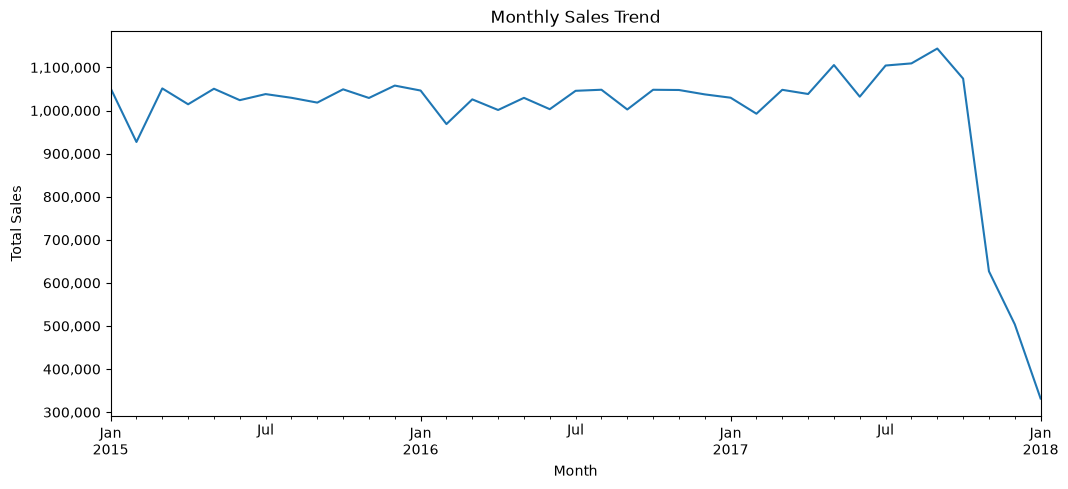

In [18]:
import matplotlib.ticker as mticker
fig, ax = plt.subplots()

monthly_sales = df_clean.groupby(df_clean['Order_Date'].dt.to_period('M'))['Sales'].sum()
plt.gca()

monthly_sales.plot(kind='line', figsize=(12, 5), title='Monthly Sales Trend')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

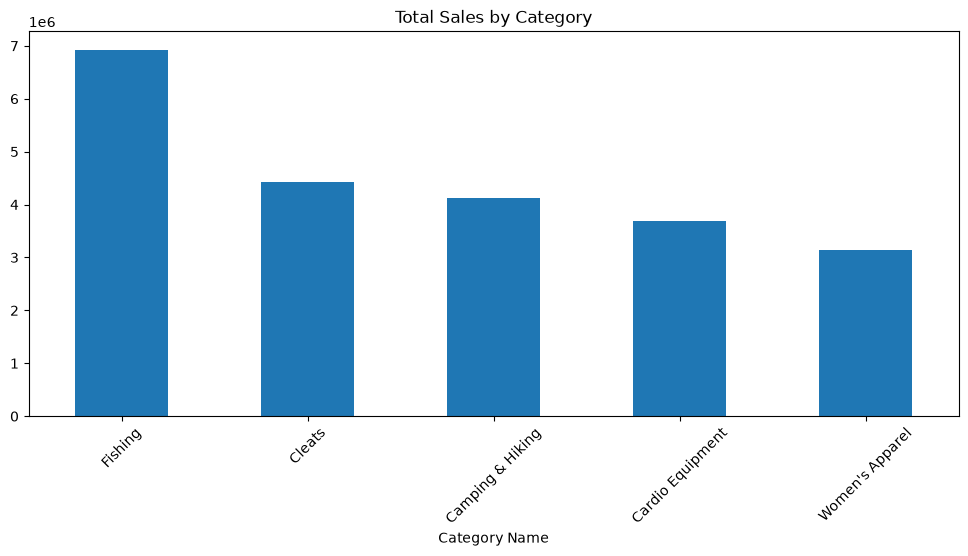

In [10]:
category_summary = (
    df_clean
    .groupby('Category Name')
    .agg(
        Total_sales=('Sales', 'sum'),
        Total_profit=('Profit_per_order', 'sum')
    )
    .round(2)
    .reset_index()
)

category_summary['profit_margin'] = (category_summary['Total_profit'] / category_summary['Total_sales']).round(3)

category_summary.sort_values(by='Total_sales', ascending=False).head().plot(
    x='Category Name', y='Total_sales', kind='bar', figsize=(12, 5), title='Total Sales by Category', legend=False
)
plt.xticks(rotation=45)
plt.show()


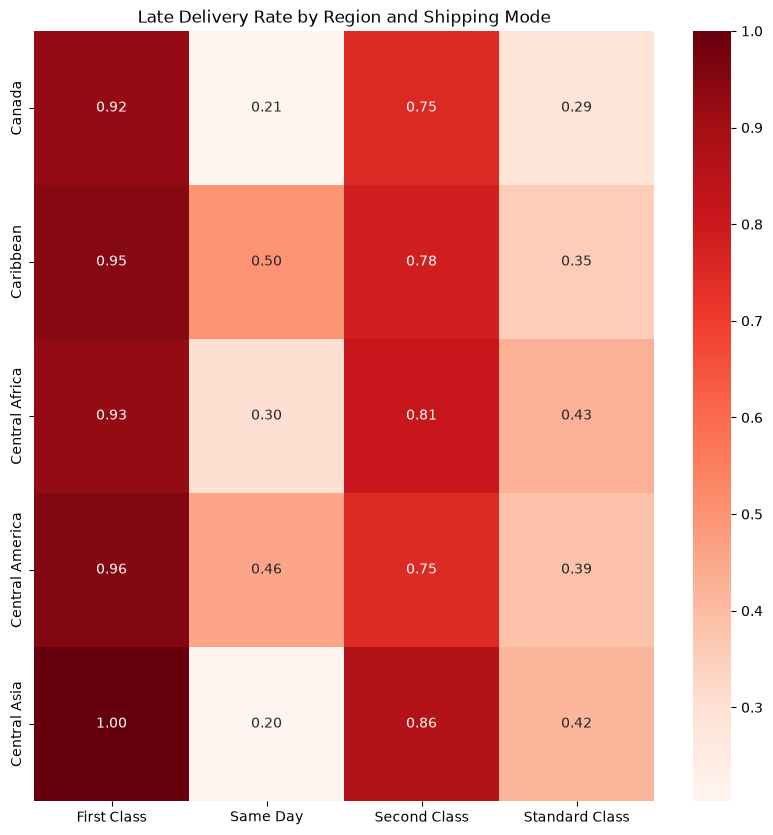

In [15]:
heatmap_data = df_clean.pivot_table(
    index='Order_region',
    columns='Shipping_mode',
    values='Late_delivery_risk',
    aggfunc='mean'
).head(5)

plt.figure(figsize=(10, 10))
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='Reds')
plt.title('Late Delivery Rate by Region and Shipping Mode')
plt.ylabel('')
plt.xlabel('')
plt.show()